# Trend Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils import (
    fetch_prices, fetch_index,
    calc_monthly_returns, 
    calc_trend_regime, calc_regime_stats,
    calc_trend_quintile,
    calc_momentum_signals, calc_quintile_from_signals,
    grid_search_quintile,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [2]:
# ---- Configuration ----
proxy = None                                                # e.g. "http://proxy:8080"

# Ticker list & display names
tickers = [
    "SMH", "IGV", "XAR", "XBI", "XME", "GDX", "XOP", "PAVE",
    "MGK", "MGV", "IWM", "SCHD", "USMV", "MTUM", "QUAL",
    "372330.KS", "487230.KS", "BOTZ", "SKYY", "ICLN", "AIQ"
]

ticker_names = {
    "SMH":       "Semiconductors",
    "IGV":       "Software",
    "XAR":       "Aerospace",
    "XBI":       "Biotech",
    "XME":       "Metals&Mining",
    "GDX":       "GoldMiners",
    "XOP":       "Oil&Gas",
    "PAVE":      "InfraDev",
    "MGK":       "Growth",
    "MGV":       "Value",
    "IWM":       "Small",
    "SCHD":      "Dividend",
    "USMV":      "MinVol",
    "MTUM":      "Momentum",
    "QUAL":      "Quality",
    "372330.KS": "HangSengTech",
    "487230.KS": "AI-Power",
    "BOTZ":      "Robot",
    "SKYY":      "CloudComputing",
    "ICLN":      "CleanEnergy",
    "AIQ":       "AI-Tech"
}

# Trend lookback (months)
fast_months = 2
slow_months = 12

# Composite rank weights
w_slow = 0.8
w_fast = 0.2

# Snapshot date for Quadrant Scatter (None = latest available month-end)
# e.g. "2024-12-31" or "2024-12" — picks the nearest month-end ≤ this date
snapshot_date = "2026-03-31"

## 1. Trend Cycle Quadrant Analysis

In [3]:
prices_multi = fetch_prices(tickers, start="1900-01-01", end="2026-12-31", proxy=proxy)
monthly_ret_multi = calc_monthly_returns(prices_multi)
regimes = calc_trend_regime(monthly_ret_multi, fast_months=fast_months, slow_months=slow_months)

# Resolve snapshot date: None → latest, otherwise nearest month-end ≤ snapshot_date
all_dates = regimes["date"]
if snapshot_date is None:
    snap_date = all_dates.max()
else:
    target = pd.Timestamp(snapshot_date)
    eligible = all_dates[all_dates <= target]
    if len(eligible) == 0:
        raise ValueError(f"No regime data on/before {snapshot_date}; earliest available is {all_dates.min().date()}")
    snap_date = eligible.max()

latest_date = snap_date  # kept name for downstream cells
latest = regimes[regimes["date"] == latest_date].copy()

print(f"Snapshot date: {latest_date.strftime('%Y-%m-%d')}  (Fast={fast_months}M, Slow={slow_months}M)")
latest[["ticker", "ret_fast", "ret_slow", "regime"]]

[*********************100%***********************]  21 of 21 completed

Snapshot date: 2026-03-31  (Fast=2M, Slow=12M)


,ticker,ret_fast,ret_slow,regime
8,372330.KS,-0.140642,-0.105949,Bearish
18,487230.KS,0.071528,0.875743,Bullish
28,AIQ,-0.101982,0.285418,Correction
38,BOTZ,-0.109861,0.175169,Correction
48,GDX,-0.025796,1.010800,Correction
58,ICLN,0.007714,0.631208,Bullish
68,IGV,-0.113609,-0.100461,Bearish
78,IWM,-0.043169,0.256567,Correction
88,MGK,-0.093842,0.194027,Correction
98,MGV,-0.016534,0.149597,Correction


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


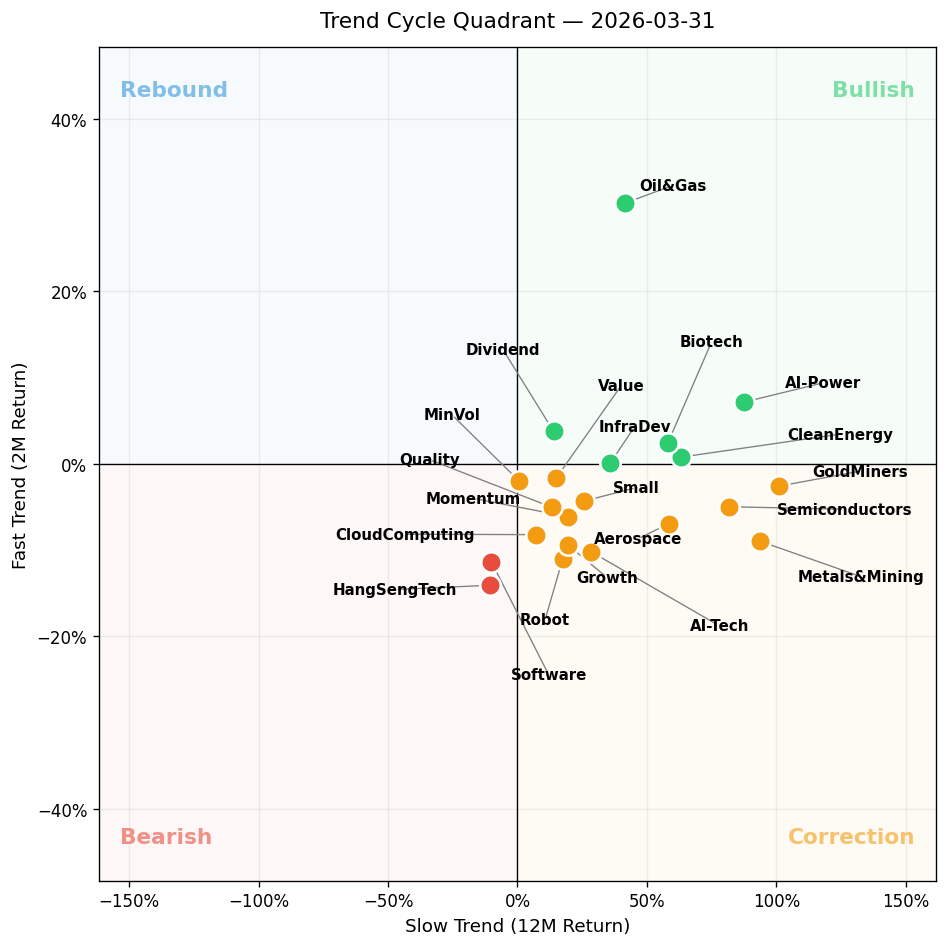

In [4]:
# Chart A: Quadrant Scatter
from adjustText import adjust_text

regime_colors = {
    "Bullish": "#2ecc71",
    "Correction": "#f39c12",
    "Bearish": "#e74c3c",
    "Rebound": "#3498db",
}

fig, ax = plt.subplots(figsize=(8, 8))

for regime_name, color in regime_colors.items():
    subset = latest[latest["regime"] == regime_name]
    ax.scatter(subset["ret_slow"], subset["ret_fast"],
              color=color, label=regime_name, s=150, zorder=5, edgecolors="white", linewidths=1.5)

# Symmetric axes centered at 0 (set BEFORE adjustText so it knows the bounds)
x_abs = max(abs(latest["ret_slow"].min()), abs(latest["ret_slow"].max())) * 1.6
y_abs = max(abs(latest["ret_fast"].min()), abs(latest["ret_fast"].max())) * 1.6
ax.set_xlim(-x_abs, x_abs)
ax.set_ylim(-y_abs, y_abs)

# Annotate with display names, avoid overlaps
texts = []
for _, row in latest.iterrows():
    name = ticker_names.get(row["ticker"], row["ticker"])
    texts.append(ax.text(row["ret_slow"], row["ret_fast"], name,
                         fontsize=9, fontweight="bold", zorder=10))
adjust_text(texts, ax=ax,
            force_text=(2.0, 2.0),
            force_points=(1.5, 1.5),
            expand=(2.0, 2.0),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.8))

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Slow Trend ({slow_months}M Return)", fontsize=11)
ax.set_ylabel(f"Fast Trend ({fast_months}M Return)", fontsize=11)
ax.set_title(f"Trend Cycle Quadrant — {latest_date.strftime('%Y-%m-%d')}", fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

# Background shading for quadrants
ax.axhspan(0, y_abs, xmin=0.5, xmax=1.0, alpha=0.04, color="#2ecc71")   # Bullish
ax.axhspan(-y_abs, 0, xmin=0.5, xmax=1.0, alpha=0.04, color="#f39c12")  # Correction
ax.axhspan(-y_abs, 0, xmin=0.0, xmax=0.5, alpha=0.04, color="#e74c3c")  # Bearish
ax.axhspan(0, y_abs, xmin=0.0, xmax=0.5, alpha=0.04, color="#3498db")   # Rebound

# Quadrant labels in corners
ax.text( x_abs*0.95,  y_abs*0.92, "Bullish",    ha="right", va="top",    fontsize=13, color="#2ecc71", alpha=0.6, weight="bold")
ax.text( x_abs*0.95, -y_abs*0.92, "Correction", ha="right", va="bottom", fontsize=13, color="#f39c12", alpha=0.6, weight="bold")
ax.text(-x_abs*0.95, -y_abs*0.92, "Bearish",    ha="left",  va="bottom", fontsize=13, color="#e74c3c", alpha=0.6, weight="bold")
ax.text(-x_abs*0.95,  y_abs*0.92, "Rebound",    ha="left",  va="top",    fontsize=13, color="#3498db", alpha=0.6, weight="bold")

# Legend outside plot area
#ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False, fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

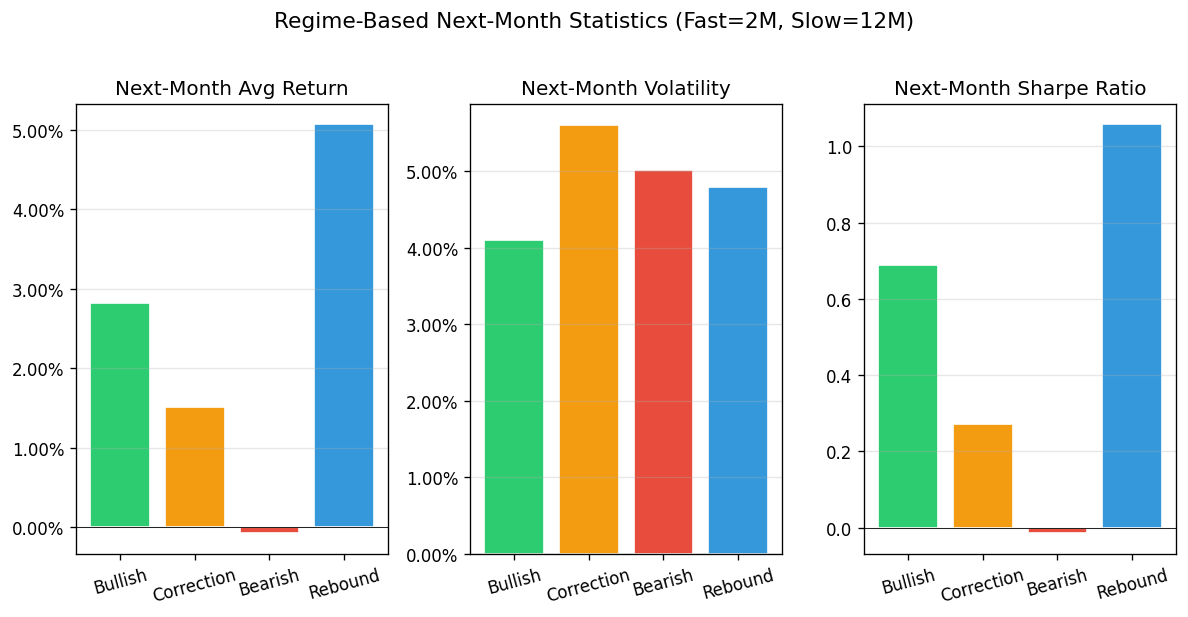

In [5]:
# Chart B: Regime Statistics
regime_stats = calc_regime_stats(monthly_ret_multi, regimes)
regime_order = ["Bullish", "Correction", "Bearish", "Rebound"]
regime_stats = regime_stats.loc[regime_order]

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
bar_colors = [regime_colors[r] for r in regime_order]

# Mean Return
axes[0].bar(regime_order, regime_stats["mean"], color=bar_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Volatility
axes[1].bar(regime_order, regime_stats["std"], color=bar_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

# Sharpe
axes[2].bar(regime_order, regime_stats["sharpe"], color=bar_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.suptitle(f"Regime-Based Next-Month Statistics (Fast={fast_months}M, Slow={slow_months}M)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Trend Quintile Analysis (Rank-Based)

In [11]:
# Quintile assignment
quintile_latest, quintile_stats = calc_trend_quintile(
    monthly_ret_multi, regimes, w_slow=w_slow, w_fast=w_fast
)

# Show current quintile assignments
quintile_latest["name"] = quintile_latest["ticker"].map(ticker_names)
display(quintile_latest[["ticker", "name", "ret_fast", "ret_slow",
                          "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))
print(f"\nLookback: Fast={fast_months}M, Slow={slow_months}M | Weights: Slow={w_slow}, Fast={w_fast}")
quintile_stats

,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
9,372330.KS,HangSengTech,-0.015423,0.001211,2.0,5.0,2.6,Q1
69,IGV,Software,0.044502,-0.113147,1.0,11.0,3.0,Q1
169,USMV,MinVol,-0.034176,0.032632,3.0,4.0,3.2,Q1
129,QUAL,Quality,0.014562,0.236635,5.0,9.0,5.8,Q1
149,SKYY,CloudComputing,0.081076,0.139041,4.0,14.0,6.0,Q2
99,MGV,Value,-0.014382,0.239541,6.0,6.0,6.0,Q2
39,BOTZ,Robot,-0.042542,0.316995,8.0,3.0,7.0,Q2
139,SCHD,Dividend,-0.009634,0.255046,7.0,8.0,7.2,Q2
89,MGK,Growth,0.089732,0.340621,9.0,15.0,10.2,Q3
79,IWM,Small,0.060182,0.435037,11.0,13.0,11.4,Q3



Lookback: Fast=2M, Slow=12M | Weights: Slow=0.8, Fast=0.2


,mean,std,sharpe
Q1,0.014545,0.028819,0.504680
Q2,0.028199,0.040915,0.689207
Q3,0.015210,0.049782,0.305537
Q4,0.029124,0.034654,0.840417
Q5,0.044945,0.075842,0.592614


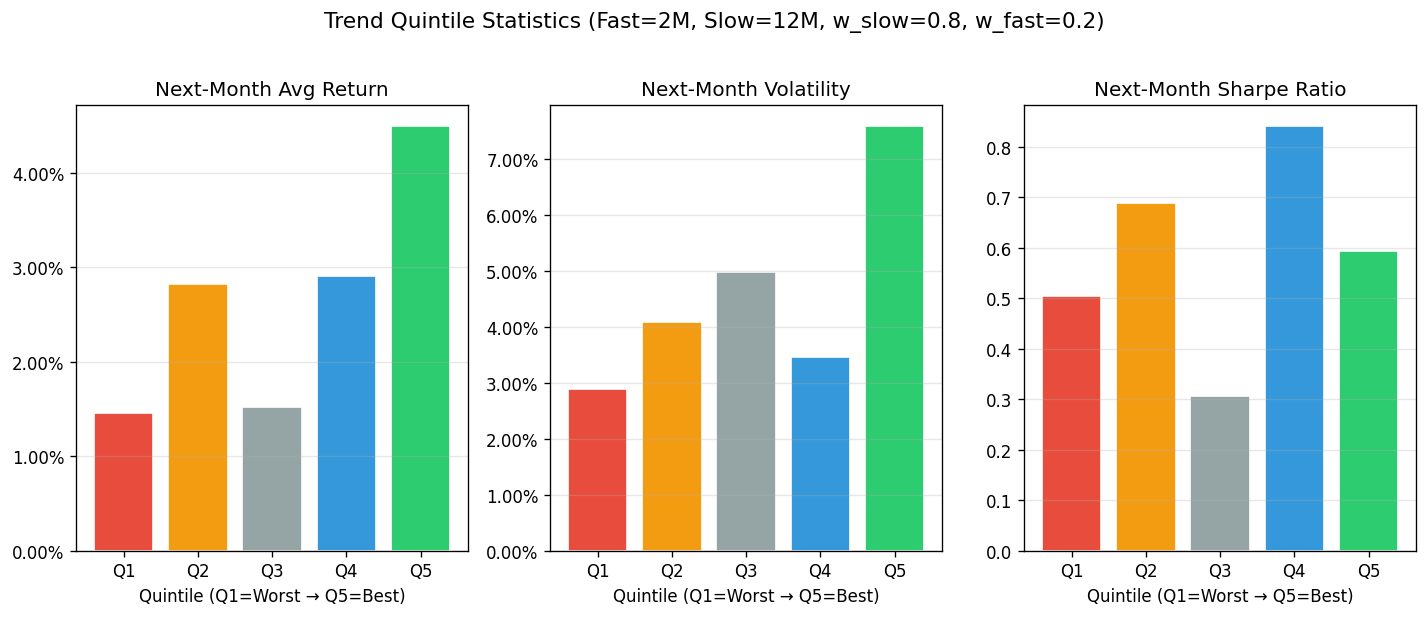

In [12]:
# Chart: Quintile Statistics
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Mean Return
axes[0].bar(q_labels, quintile_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Volatility
axes[1].bar(q_labels, quintile_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

# Sharpe
axes[2].bar(q_labels, quintile_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Trend Quintile Statistics (Fast={fast_months}M, Slow={slow_months}M, w_slow={w_slow}, w_fast={w_fast})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Grid Search — Optimal Fast/Slow Lookback & Weights

In [8]:
%%time
# Grid search: find combo that maximizes Q5-Q1 Sharpe spread
# Results sorted by: (1) fewest monotonicity violations, (2) largest spread
grid_results = grid_search_quintile(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
    weight_step=0.1,
)

n_mono = grid_results["is_monotonic"].sum()
n_near = (grid_results["mono_violations"] <= 1).sum()
print(f"Total combos tested: {len(grid_results)}")
print(f"Strictly monotonic (0 violations): {n_mono}")
print(f"Near-monotonic (≤1 violation): {n_near}")

# Show near-monotonic combos (≤1 violation), sorted by spread
near_mono = grid_results[grid_results["mono_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_mono[["fast_months", "slow_months", "w_slow", "w_fast",
           "sharpe_Q1", "sharpe_Q2", "sharpe_Q3", "sharpe_Q4", "sharpe_Q5",
           "sharpe_spread", "mono_violations"]].head(15)

Total combos tested: 165
Strictly monotonic (0 violations): 3
Near-monotonic (≤1 violation): 80

Top 15 near-monotonic combos:
CPU times: user 8.62 s, sys: 0 ns, total: 8.62 s
Wall time: 7.37 s


,fast_months,slow_months,w_slow,w_fast,sharpe_Q1,sharpe_Q2,sharpe_Q3,sharpe_Q4,sharpe_Q5,sharpe_spread,mono_violations
0,2,9,0.4,0.6,0.355866,0.572671,0.729149,0.931340,1.015271,0.659405,0
1,2,10,0.4,0.6,0.274363,0.529356,0.586426,0.876967,0.929732,0.655369,0
2,3,9,0.2,0.8,0.362059,0.614088,0.791641,0.792411,0.857723,0.495664,0
3,3,11,0.3,0.7,-0.010694,0.652337,0.786621,0.568729,0.755812,0.766506,1
4,3,10,0.3,0.7,0.090205,0.672843,0.931929,0.683356,0.827968,0.737762,1
5,3,10,0.2,0.8,0.120336,0.602506,0.855593,0.710191,0.824354,0.704018,1
6,3,11,0.2,0.8,0.063761,0.573453,0.700206,0.631082,0.755779,0.692018,1
7,3,11,0.4,0.6,0.008436,0.740022,0.959976,0.511324,0.691376,0.682940,1
8,2,10,0.2,0.8,0.271152,0.849994,0.327306,0.814836,0.944680,0.673528,1
9,2,10,0.3,0.7,0.266002,0.633977,0.517200,0.878307,0.925794,0.659792,1


Best combo (monotonic): Fast=2M, Slow=9M, w_slow=0.4, w_fast=0.6
  Q1→Q5 Sharpe: 0.356 → 0.573 → 0.729 → 0.931 → 1.015
  Spread: 0.659


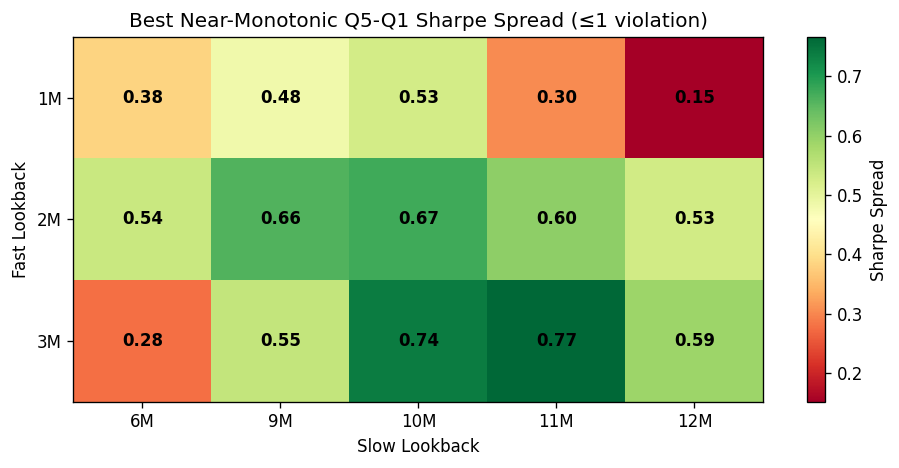

In [9]:
# Visualize grid search results
# Pick best: strictly monotonic first, then ≤1 violation, then best overall
mono_results = grid_results[grid_results["is_monotonic"]]
near_results = grid_results[grid_results["mono_violations"] <= 1]

if len(mono_results) > 0:
    best = mono_results.iloc[0]
    label = "monotonic"
elif len(near_results) > 0:
    best = near_results.iloc[0]
    label = f"near-monotonic ({int(best['mono_violations'])} violation)"
else:
    best = grid_results.iloc[0]
    label = f"{int(best['mono_violations'])} violations"

print(f"Best combo ({label}): "
      f"Fast={int(best['fast_months'])}M, Slow={int(best['slow_months'])}M, "
      f"w_slow={best['w_slow']:.1f}, w_fast={best['w_fast']:.1f}")
print(f"  Q1→Q5 Sharpe: {best['sharpe_Q1']:.3f} → {best['sharpe_Q2']:.3f} → "
      f"{best['sharpe_Q3']:.3f} → {best['sharpe_Q4']:.3f} → {best['sharpe_Q5']:.3f}")
print(f"  Spread: {best['sharpe_spread']:.3f}")

# Heatmap: for each (fast, slow) pair, show best sharpe_spread among ≤1 violation combos
pivot_src = near_results if len(near_results) > 0 else grid_results
hm_pivot = pivot_src.groupby(["fast_months", "slow_months"])["sharpe_spread"].max().unstack()

if not hm_pivot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(hm_pivot.values, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(hm_pivot.columns)))
    ax.set_xticklabels([f"{int(c)}M" for c in hm_pivot.columns])
    ax.set_yticks(range(len(hm_pivot.index)))
    ax.set_yticklabels([f"{int(r)}M" for r in hm_pivot.index])
    ax.set_xlabel("Slow Lookback")
    ax.set_ylabel("Fast Lookback")
    ax.set_title("Best Near-Monotonic Q5-Q1 Sharpe Spread (≤1 violation)")

    for i in range(len(hm_pivot.index)):
        for j in range(len(hm_pivot.columns)):
            val = hm_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Sharpe Spread")
    plt.tight_layout()
    plt.show()

Selected: #2 → Fast=3M, Slow=9M, w_slow=0.2, w_fast=0.8  (violations=0, spread=0.496)


,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
12,372330.KS,HangSengTech,-0.116279,-0.035464,3.0,1.0,1.4,Q1
90,IGV,Software,-0.056583,-0.236969,1.0,3.0,2.6,Q1
233,XAR,Aerospace,-0.060078,0.188108,10.0,2.0,3.6,Q1
220,USMV,MinVol,-0.005504,0.028246,4.0,5.0,4.8,Q1
194,SKYY,CloudComputing,-0.004953,-0.037043,2.0,6.0,5.2,Q2
51,BOTZ,Robot,0.001072,0.121043,6.0,7.0,6.8,Q2
259,XME,Metals&Mining,-0.007303,0.611153,19.0,4.0,7.0,Q2
129,MGV,Value,0.018273,0.167730,8.0,9.0,8.8,Q2
168,QUAL,Quality,0.026792,0.135092,7.0,10.0,9.4,Q3
116,MGK,Growth,0.038984,0.110045,5.0,11.0,9.8,Q3


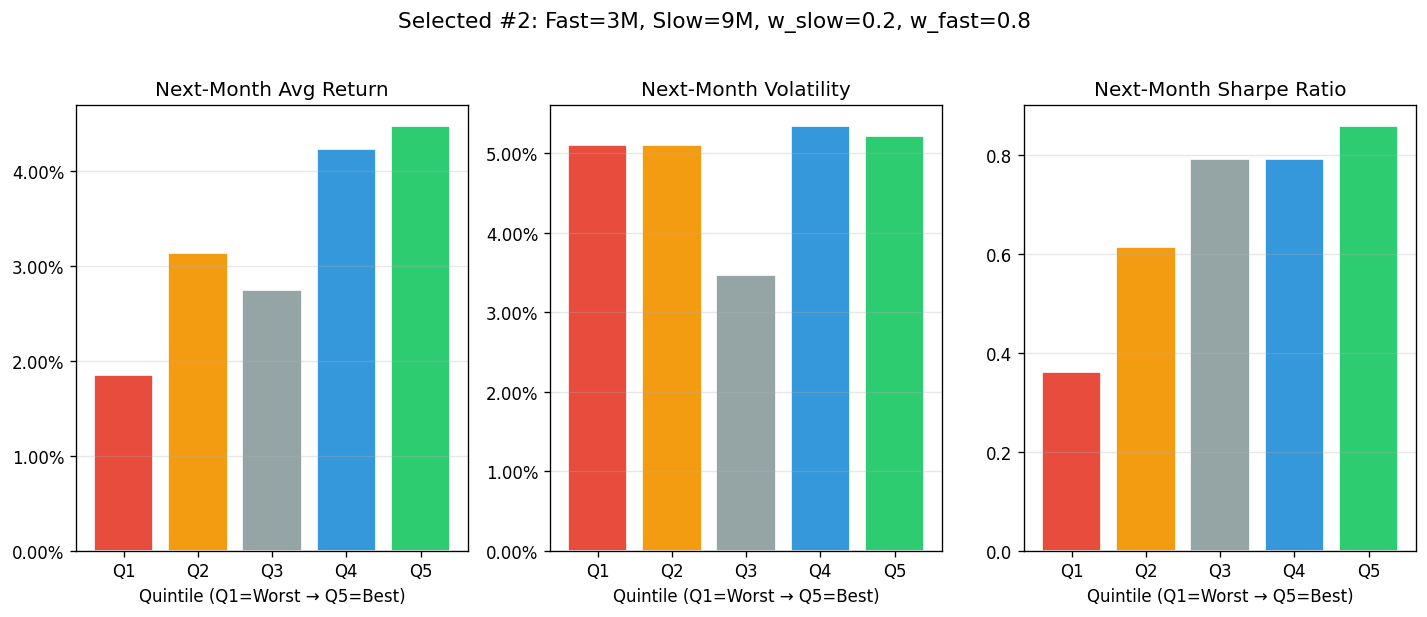

In [10]:
# ---- Select combo from near-monotonic results (0-indexed from table above) ----
selected_rank = 2  # Change this: 0 = 1st row, 2 = 3rd row, etc.

# Rerun quintile analysis with selected combo from grid search
sel = near_mono.iloc[selected_rank]
sel_fast = int(sel["fast_months"])
sel_slow = int(sel["slow_months"])
sel_ws = sel["w_slow"]
sel_wf = sel["w_fast"]

print(f"Selected: #{selected_rank} → Fast={sel_fast}M, Slow={sel_slow}M, "
      f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}  "
      f"(violations={int(sel['mono_violations'])}, spread={sel['sharpe_spread']:.3f})")

sel_signals = calc_momentum_signals(monthly_ret_multi, fast_months=sel_fast, slow_months=sel_slow)
sel_q_latest, sel_q_stats = calc_quintile_from_signals(
    monthly_ret_multi, sel_signals, w_slow=sel_ws, w_fast=sel_wf
)

# Show assignments
sel_q_latest["name"] = sel_q_latest["ticker"].map(ticker_names)
display(sel_q_latest[["ticker", "name", "ret_fast", "ret_slow",
                       "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))

# Chart
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(q_labels, sel_q_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(q_labels, sel_q_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(q_labels, sel_q_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Selected #{selected_rank}: Fast={sel_fast}M, Slow={sel_slow}M, "
             f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()